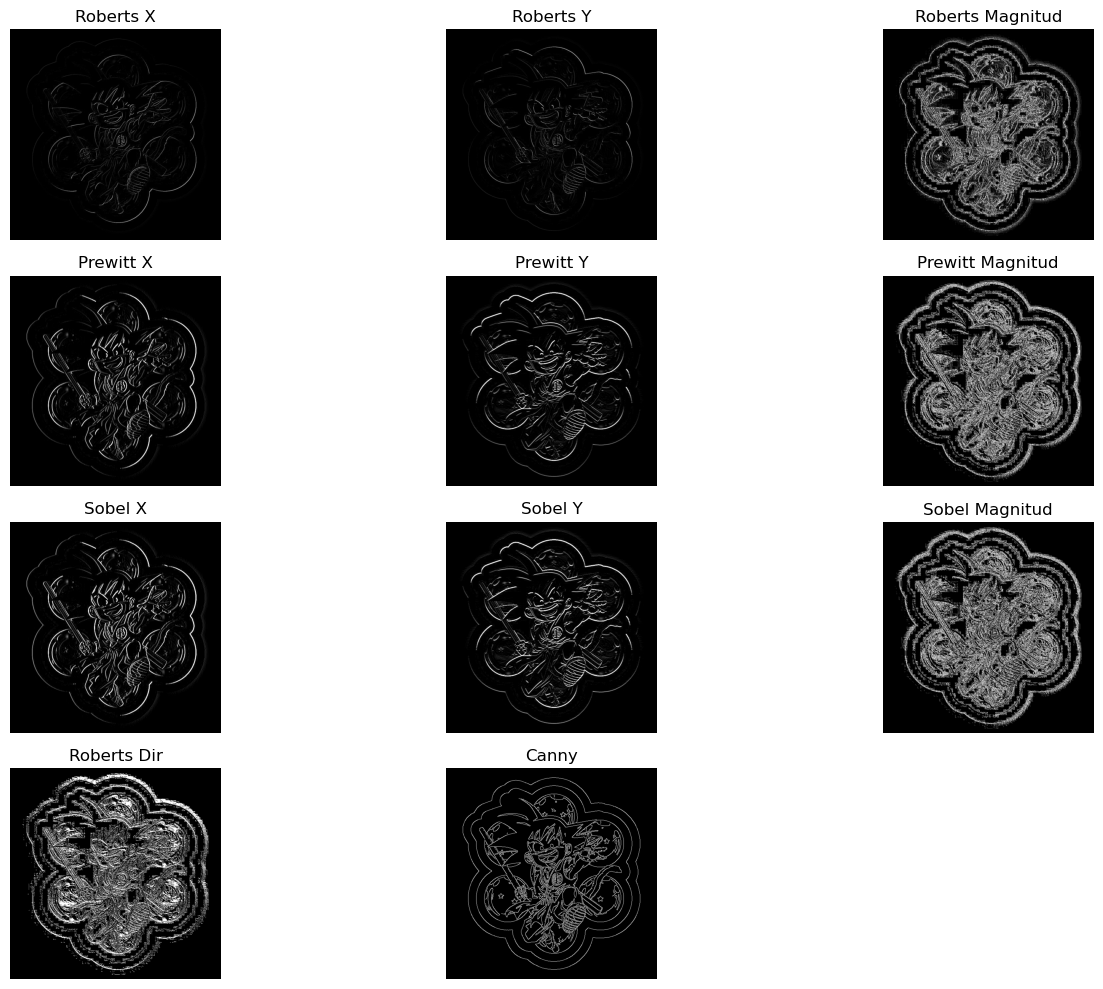

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('goku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
robertx = np.array ([[-1,0], [0,1]])
roberty = np.array ([[0,1], [-1,0]])
robx_img = cv2.filter2D(gray, -1, robertx)
roby_img = cv2.filter2D(gray, -1, roberty)
rob_grad = np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img) * (180 / np.pi)

# prewitt

prewittx = np.array ([[-1,0,1], [-1,0,1], [-1,0,1]])
prewitty = np.array ([[1,1,1], [0,0,0], [-1,-1,-1]])
prex_img = cv2.filter2D(gray, -1, prewittx)
prey_img = cv2.filter2D(gray, -1, prewitty)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
preww_dir = np.arctan2(prex_img, prey_img)

# solbel

solbel_x = np.array ([[-1,0,1], [-2,0,2], [-1,0,1]])
solbel_y = np.array ([[1,2,1], [0,0,0], [-1,-2,-1]])
solbelx_img = cv2.filter2D(gray, -1, solbel_x)
solbely_img = cv2.filter2D(gray, -1, solbel_y)
solbel_mag = np.sqrt(solbelx_img**2 + solbely_img**2)
solbel_dir = np.arctan2(solbely_img, solbelx_img)

cany_img = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(14, 10))

plt.subplot(4,3,1); plt.imshow(robx_img, cmap='gray'); plt.title('Roberts X'); plt.axis('off')
plt.subplot(4,3,2); plt.imshow(roby_img, cmap='gray'); plt.title('Roberts Y'); plt.axis('off')
plt.subplot(4,3,3); plt.imshow(rob_grad, cmap='gray'); plt.title('Roberts Magnitud'); plt.axis('off')

plt.subplot(4,3,4); plt.imshow(prex_img, cmap='gray'); plt.title('Prewitt X'); plt.axis('off')
plt.subplot(4,3,5); plt.imshow(prey_img, cmap='gray'); plt.title('Prewitt Y'); plt.axis('off')
plt.subplot(4,3,6); plt.imshow(prewitt_mag, cmap='gray'); plt.title('Prewitt Magnitud'); plt.axis('off')

plt.subplot(4,3,7); plt.imshow(solbelx_img, cmap='gray'); plt.title('Sobel X'); plt.axis('off')
plt.subplot(4,3,8); plt.imshow(solbely_img, cmap='gray'); plt.title('Sobel Y'); plt.axis('off')
plt.subplot(4,3,9); plt.imshow(solbel_mag, cmap='gray'); plt.title('Sobel Magnitud'); plt.axis('off')

plt.subplot(4,3,10); plt.imshow(rob_grad_dir, cmap='gray'); plt.title('Roberts Dir'); plt.axis('off')
plt.subplot(4,3,11); plt.imshow(cany_img, cmap='gray'); plt.title('Canny'); plt.axis('off')

plt.tight_layout()
plt.show()

SOBEL

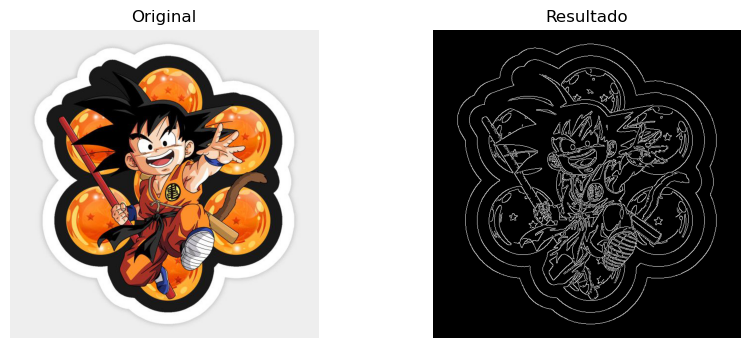

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion filtro gauss\
    img_gris = cv2.GaussianBlur(img_gris,(3,3),0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    #mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _,border = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #Operacion MORPH Donde Unimos Bordes Rotos
    kernel_n = np.ones((2,2), np.uint8)
    bordes = cv2.morphologyEx(border, cv2.MORPH_CLOSE, kernel_n)
    return bordes

img = cv2.imread('goku.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
bordes = cv2.Canny(gris, 100, 200)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(bordes, cmap='gray')
plt.title('Resultado')
plt.axis('off')

plt.show()

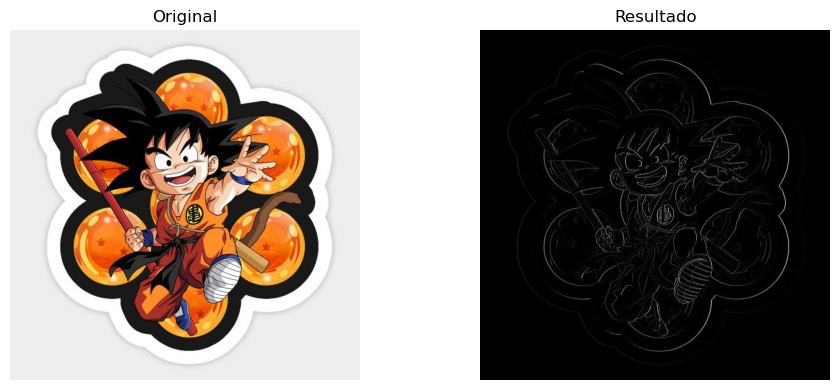

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    robertx = np.array ([[-1,0], [0,1]], dtype=np.float32)
    roberty = np.array ([[0,1], [-1,0]], dtype=np.float32)
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)
    return roberts

img = cv2.imread('goku.jpg')
resultado = filtro_roberts(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resultado, cmap='gray')
plt.title('Resultado')
plt.axis('off')

plt.tight_layout()
plt.show()